# Food Delivery Data Visualization Portfolio (Day 14)
This notebook explores the Food Delivery Business Performance Dataset to uncover meaningful patterns regarding revenue, order channels, logistics, and customer satisfaction.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for better aesthetics
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('Day14_Food_Delivery_Visualization_Dataset.csv')
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

df.head()


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


## 1. Line Plot: Revenue Trend Over Time
**Interpretation:** The line plot reveals that revenue experiences significant peaks during June and December. This suggests strong seasonal demand, likely tied to summer and winter holidays.


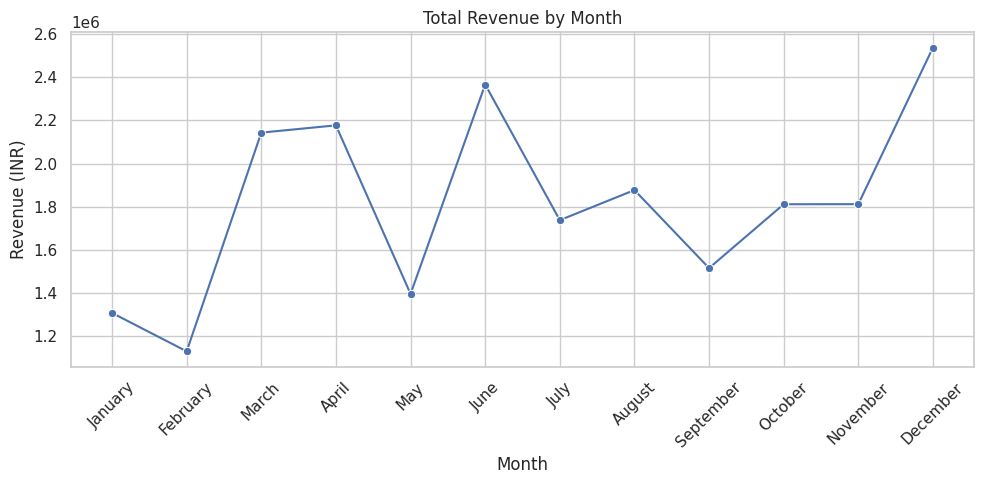

In [2]:
plt.figure(figsize=(10, 5))
monthly_revenue = df.groupby('Month')['Revenue'].sum().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
)
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')
plt.tight_layout()
plt.show()


## 2. Bar Chart: City Performance Comparison
**Interpretation:** Bengaluru and Delhi are the top-performing cities by a significant margin, generating the highest total revenue. Kochi and Chandigarh represent the lowest revenue tiers in this dataset.


/tmp/ipykernel_5795/2854864246.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='viridis')


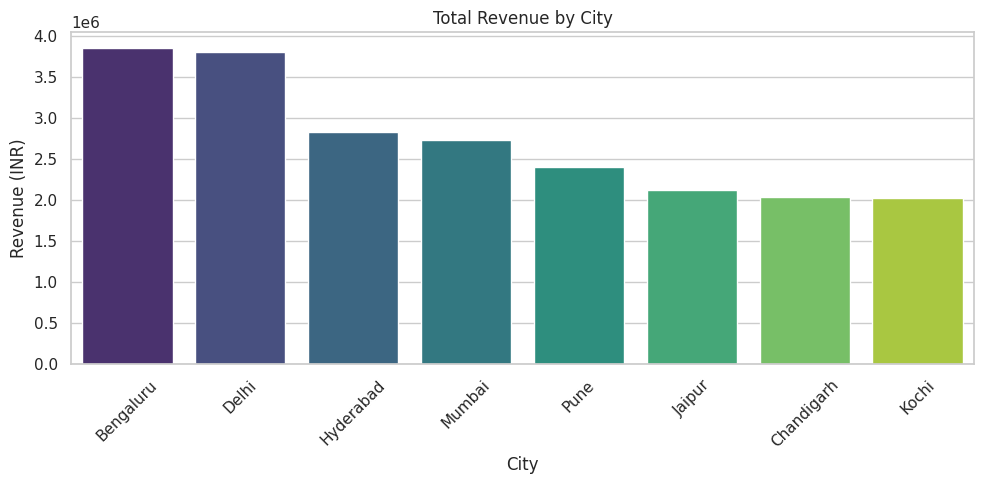

In [3]:
plt.figure(figsize=(10, 5))
city_revenue = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)
sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue (INR)')
plt.tight_layout()
plt.show()


## 3. Count Plot: Order Channel Popularity
**Interpretation:** The proprietary mobile App is overwhelmingly the most popular channel for placing orders, heavily outpacing both the Website and third-party Partner Platforms.


/tmp/ipykernel_5795/1856353697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Order_Channel', palette='Set2')


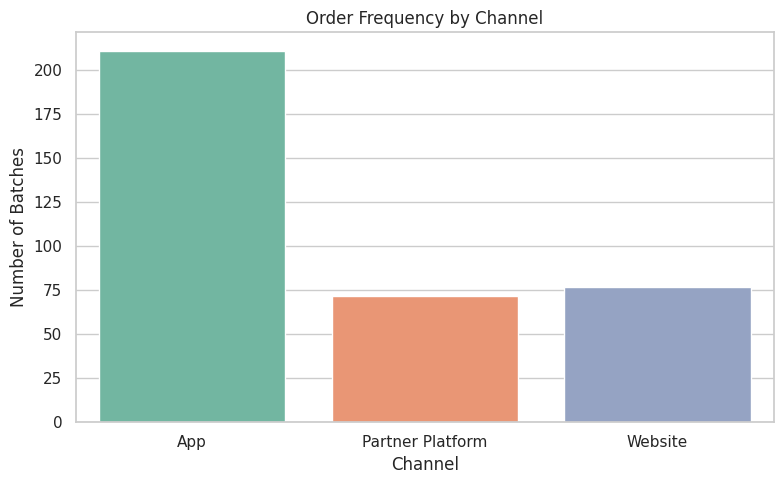

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Order_Channel', palette='Set2')
plt.title('Order Frequency by Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Batches')
plt.tight_layout()
plt.show()


## 4. Histogram: Average Order Value Distribution
**Interpretation:** The histogram displays a roughly normal, slightly right-skewed distribution. The majority of average order values cluster tightly between 300 and 450 INR.


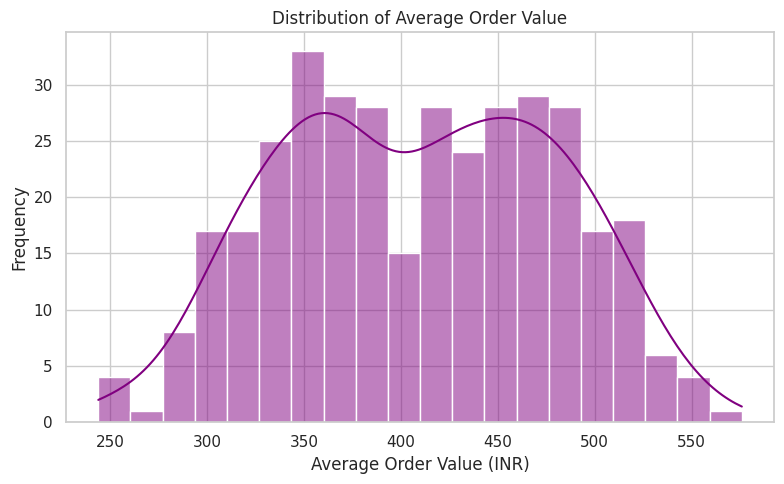

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Average_Order_Value'], bins=20, kde=True, color='purple')
plt.title('Distribution of Average Order Value')
plt.xlabel('Average Order Value (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## 5. Box Plot: Delivery Time by Weather Condition
**Interpretation:** Weather has a severe impact on performance. Rainy conditions push the median delivery time close to 39 minutes with a wide variance, whereas Clear weather allows for much faster deliveries averaging around 30 minutes.


/tmp/ipykernel_5795/1630226413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weather', y='Avg_Delivery_Minutes', palette='coolwarm')


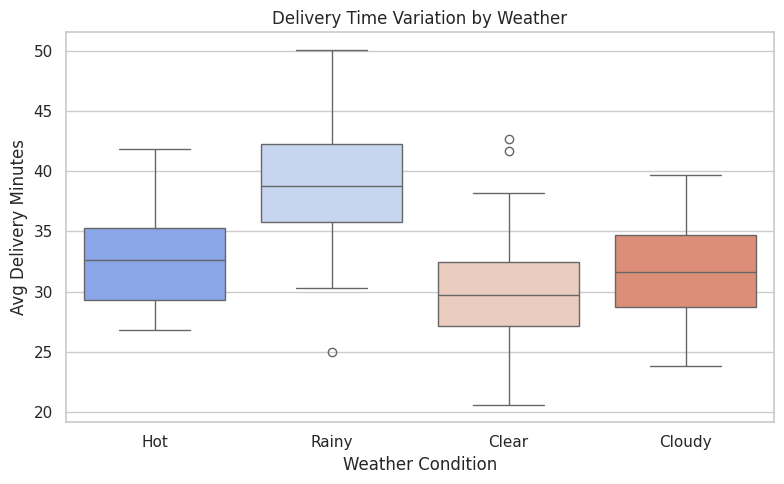

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Weather', y='Avg_Delivery_Minutes', palette='coolwarm')
plt.title('Delivery Time Variation by Weather')
plt.xlabel('Weather Condition')
plt.ylabel('Avg Delivery Minutes')
plt.tight_layout()
plt.show()


## 6. Violin Plot: Customer Ratings by Cuisine
**Interpretation:** Healthy and Healthy-adjacent cuisines tend to have higher and more tightly grouped customer ratings. In contrast, categories like Fast Food and Chinese show a wider spread with lower average ratings.


/tmp/ipykernel_5795/2605425855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Cuisine', y='Customer_Rating', palette='magma')


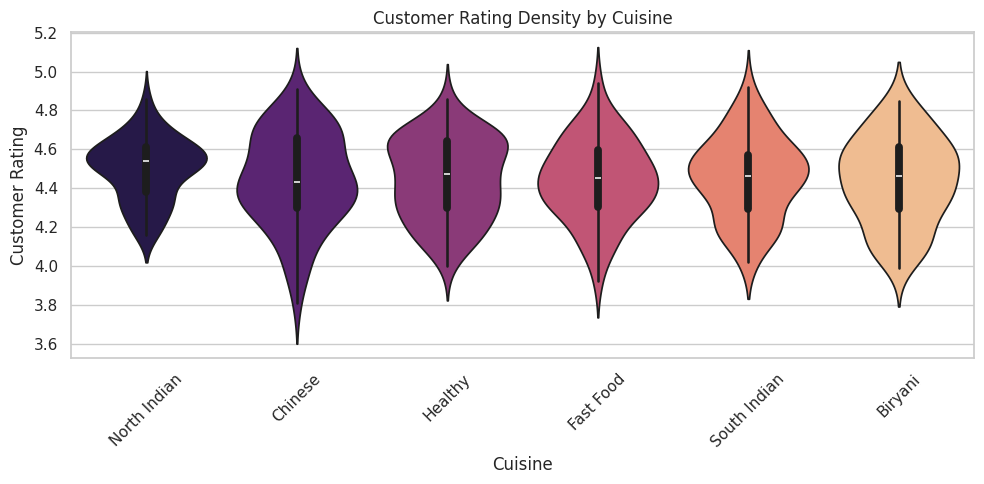

In [7]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='Cuisine', y='Customer_Rating', palette='magma')
plt.xticks(rotation=45)
plt.title('Customer Rating Density by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.show()


## 7. Scatter Plot: Delivery Time vs. Customer Rating
**Interpretation:** There is a distinct negative correlation: as delivery time increases, customer ratings consistently decline. The plot also visually reinforces that rainy weather clusters around the longer delivery times and lower ratings.


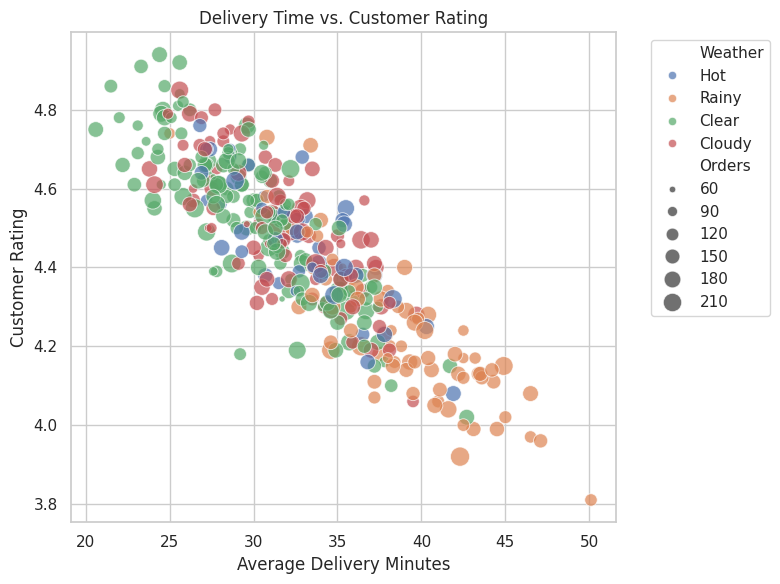

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Avg_Delivery_Minutes', y='Customer_Rating',
                hue='Weather', size='Orders', sizes=(20, 200), alpha=0.7)
plt.title('Delivery Time vs. Customer Rating')
plt.xlabel('Average Delivery Minutes')
plt.ylabel('Customer Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 8. Correlation Heatmap: Overall Variable Relationships
**Interpretation:** The heatmap confirms the strong negative correlation (-0.88) between delivery minutes and customer rating. Interestingly, it also reveals that Marketing Spend has a very weak correlation (0.20) with Revenue, indicating that higher marketing budgets aren't strongly translating to higher sales.


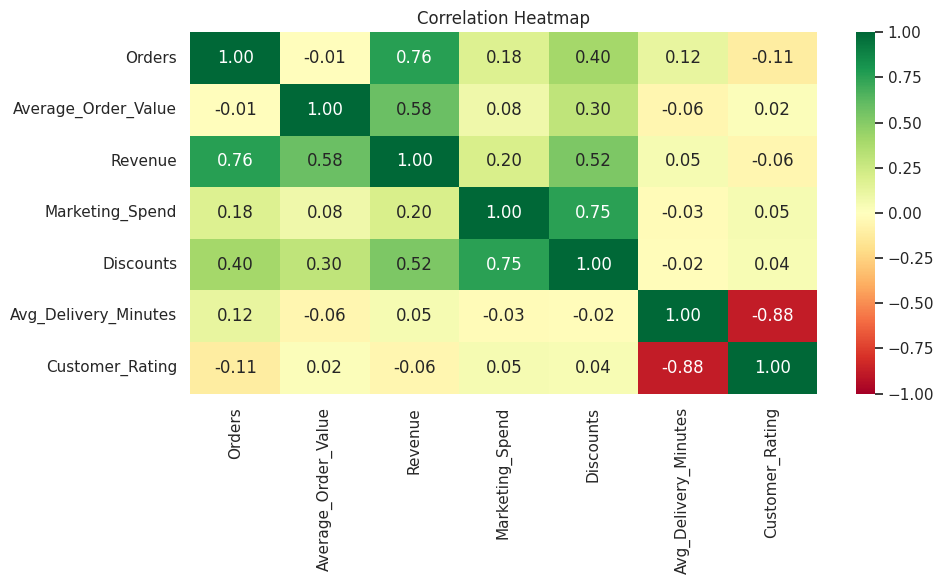

In [9]:
plt.figure(figsize=(10, 6))
numeric_cols = ['Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend',
                'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## Summary of Most Important Findings
* **Operational Bottleneck:** Rainy weather severely impacts delivery times, which directly crashes customer satisfaction.
* **Platform Focus:** The mobile app is the absolute core of the business channel.
* **Marketing Review Needed:** Current marketing spend shows a weak correlation with actual revenue generation, suggesting a need to audit marketing efficiency.
* **Seasonal Peaks:** Demand naturally spikes in June and December, requiring adequate logistics planning during those months.
